<a href="https://colab.research.google.com/github/njwbilll/Tugas-2_scikit-learn-Cookbook-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/12_Cross_Validation_and_Model_Evaluation_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 12: Cross-Validation and Model Evaluation Techniques

**Referensi:** scikit-learn Cookbook, Third Edition - John Sukup (Packt Publishing, 2025)

---

## Ringkasan Chapter

Chapter 12 membahas teknik-teknik evaluasi model yang robust untuk memastikan bahwa model machine learning dapat menggeneralisasi dengan baik pada data yang belum pernah dilihat sebelumnya. Seperti yang dikatakan statistikawan George Box: *"All models are wrong, but some are useful."* Chapter ini mengeksplorasi cross-validation, metrik evaluasi lanjutan, pemilihan model, dan cara mendiagnosis masalah overfitting/underfitting menggunakan learning curve dan validation curve.

### Topik yang Dibahas:
1. Pengantar cross-validation (K-Fold dan Stratified K-Fold)
2. Metode cross-validation lanjutan (LOOCV dan Nested CV)
3. Implementasi cross-validation di scikit-learn
4. Teknik pemilihan model (GridSearchCV dan RandomizedSearchCV)
5. Evaluasi kemampuan generalisasi model (Learning Curve dan Validation Curve)

---

## Setup: Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(2024)
print("Library berhasil diimport.")

Library berhasil diimport.


---
## 1. Pengantar Cross-Validation

### Penjelasan Teori

**Cross-validation** adalah teknik dasar dalam machine learning untuk mengevaluasi seberapa baik sebuah model akan berjalan pada data yang belum pernah dilihat sebelumnya (data baru di dunia nyata).

**Mengapa tidak cukup hanya train-test split biasa?**
- Satu kali pemisahan data bisa menghasilkan estimasi performa yang berfluktuasi tergantung data mana yang masuk ke train set dan test set.
- Jika test set kebetulan "mudah", model terlihat sangat bagus; jika "sulit", model terlihat buruk.
- Cross-validation mengulangi proses ini beberapa kali dengan subset yang berbeda, menghasilkan estimasi yang lebih stabil dan representatif.

**K-Fold Cross-Validation:**
1. Dataset dibagi menjadi **k bagian** (folds) yang sama besar.
2. Model dilatih pada k-1 folds dan diuji pada 1 fold yang tersisa.
3. Proses diulang k kali, setiap fold pernah menjadi test set satu kali.
4. Hasil akhir adalah rata-rata dari k evaluasi tersebut.

**Stratified K-Fold:**
Variasi K-Fold yang mempertahankan proporsi kelas yang sama di setiap fold. Sangat penting untuk dataset yang tidak seimbang (imbalanced) karena memastikan setiap fold merepresentasikan distribusi kelas secara keseluruhan.

**Pemilihan nilai k:**
- `k=5`: Keseimbangan baik antara komputasi dan estimasi.
- `k=10`: Estimasi lebih stabil, komputasi lebih lama.
- Semakin kecil k, semakin besar bias; semakin besar k, semakin besar variance estimasi.

In [2]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset klasifikasi sintetis
X, y = make_classification(
    n_samples=500, n_features=10, n_informative=8,
    n_redundant=2, n_classes=2, random_state=2024
)

print(f"Shape dataset: {X.shape}")
print(f"Distribusi kelas:")
print(f"  Kelas 0: {(y == 0).sum()}")
print(f"  Kelas 1: {(y == 1).sum()}")

Shape dataset: (500, 10)
Distribusi kelas:
  Kelas 0: 250
  Kelas 1: 250


In [3]:
# K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=2024)

accuracies_kf = []
for fold_num, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies_kf.append(acc)
    print(f"  Fold {fold_num}: Accuracy = {acc:.4f}")

print(f"\nRata-rata Accuracy (KFold): {np.mean(accuracies_kf):.4f}")
print(f"Std Deviation:              {np.std(accuracies_kf):.4f}")

  Fold 1: Accuracy = 0.7200
  Fold 2: Accuracy = 0.7200
  Fold 3: Accuracy = 0.8800
  Fold 4: Accuracy = 0.7100
  Fold 5: Accuracy = 0.7500

Rata-rata Accuracy (KFold): 0.7560
Std Deviation:              0.0634


In [4]:
# Stratified K-Fold Cross-Validation
strat_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2024)

accuracies_skf = []
for fold_num, (train_index, test_index) in enumerate(strat_kf.split(X, y), 1):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies_skf.append(acc)
    print(f"  Fold {fold_num}: Accuracy = {acc:.4f}")

print(f"\nRata-rata Accuracy (StratifiedKFold): {np.mean(accuracies_skf):.4f}")
print(f"Std Deviation:                        {np.std(accuracies_skf):.4f}")

  Fold 1: Accuracy = 0.7900
  Fold 2: Accuracy = 0.7600
  Fold 3: Accuracy = 0.7600
  Fold 4: Accuracy = 0.7600
  Fold 5: Accuracy = 0.7600

Rata-rata Accuracy (StratifiedKFold): 0.7660
Std Deviation:                        0.0120


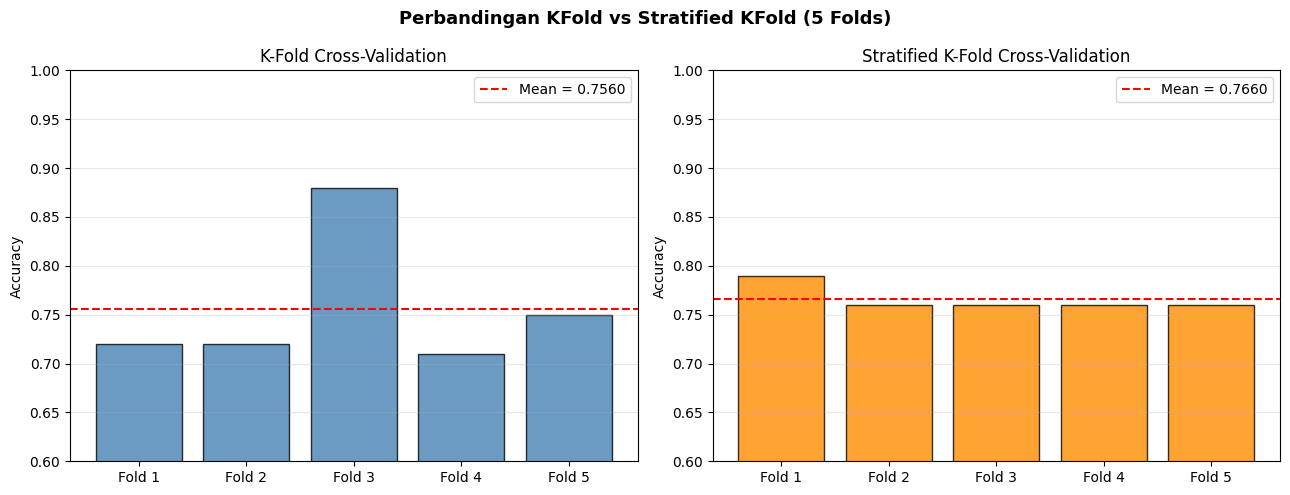

Kesimpulan: StratifiedKFold memberikan estimasi lebih stabil
karena setiap fold memiliki distribusi kelas yang representatif.


In [5]:
# Visualisasi perbandingan distribusi accuracy per fold
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

folds_x = [f'Fold {i}' for i in range(1, 6)]
ax1.bar(folds_x, accuracies_kf, color='steelblue', edgecolor='k', alpha=0.8)
ax1.axhline(np.mean(accuracies_kf), color='red', linestyle='--',
            label=f'Mean = {np.mean(accuracies_kf):.4f}')
ax1.set_ylim(0.6, 1.0)
ax1.set_title('K-Fold Cross-Validation')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

ax2.bar(folds_x, accuracies_skf, color='darkorange', edgecolor='k', alpha=0.8)
ax2.axhline(np.mean(accuracies_skf), color='red', linestyle='--',
            label=f'Mean = {np.mean(accuracies_skf):.4f}')
ax2.set_ylim(0.6, 1.0)
ax2.set_title('Stratified K-Fold Cross-Validation')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Perbandingan KFold vs Stratified KFold (5 Folds)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Kesimpulan: StratifiedKFold memberikan estimasi lebih stabil")
print(f"karena setiap fold memiliki distribusi kelas yang representatif.")

---
## 2. Metode Cross-Validation Lanjutan

### Penjelasan Teori

**Leave-One-Out Cross-Validation (LOOCV):**
Bentuk ekstrem dari K-Fold di mana k = jumlah sampel. Setiap iterasi menggunakan satu sampel sebagai test set dan sisanya sebagai training set.
- **Keunggulan**: Hampir tidak ada bias dalam estimasi (menggunakan hampir semua data untuk training).
- **Kelemahan**: Sangat mahal secara komputasi untuk dataset besar. Variance estimasi juga tinggi karena setiap model dilatih hampir sama.
- **Kapan digunakan**: Dataset sangat kecil di mana tidak ada cukup data untuk validasi konvensional.

**Nested Cross-Validation:**
Teknik yang menggabungkan hyperparameter tuning dan evaluasi model dalam satu framework tanpa kebocoran informasi (data leakage).
- **Inner loop**: Melakukan hyperparameter tuning (misalnya GridSearchCV dengan k-fold).
- **Outer loop**: Mengevaluasi performa model terbaik dari inner loop.
- **Mengapa penting**: Jika kita mengoptimalkan hyperparameter menggunakan seluruh data, lalu mengevaluasi pada data yang sama, hasilnya akan terlalu optimis karena model telah "melihat" data test secara tidak langsung.
- Nested CV memberikan estimasi performa yang lebih jujur dan realistis.

In [6]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import (
    LeaveOneOut, GridSearchCV, cross_val_score
)
from sklearn.linear_model import Ridge

# Load dataset regresi
data = load_diabetes()
X_diab = data.data
y_diab = data.target

print(f"Dataset Diabetes:")
print(f"  Shape: {X_diab.shape}")
print(f"  Target range: [{y_diab.min():.1f}, {y_diab.max():.1f}]")

Dataset Diabetes:
  Shape: (442, 10)
  Target range: [25.0, 346.0]


In [7]:
# LOOCV - Leave One Out Cross Validation
loo = LeaveOneOut()
model_ridge = Ridge(alpha=1.0)

scores_loo = cross_val_score(
    model_ridge, X_diab, y_diab,
    cv=loo, scoring='neg_mean_squared_error'
)

loocv_mse = -np.mean(scores_loo)
print(f"Leave-One-Out Cross-Validation:")
print(f"  Jumlah iterasi: {len(scores_loo)} (= jumlah sampel)")
print(f"  Mean MSE: {loocv_mse:.3f}")
print(f"  RMSE:     {np.sqrt(loocv_mse):.3f}")

Leave-One-Out Cross-Validation:
  Jumlah iterasi: 442 (= jumlah sampel)
  Mean MSE: 3327.655
  RMSE:     57.686


In [8]:
# Nested Cross-Validation
param_grid_ridge = {"alpha": [0.01, 0.1, 1, 10, 100]}

# Inner loop: GridSearchCV (hyperparameter tuning)
# Outer loop: cross_val_score (evaluasi generalisasi)
nested_scores = cross_val_score(
    GridSearchCV(Ridge(), param_grid_ridge, cv=5, scoring='r2'),
    X_diab, y_diab, cv=5, scoring='r2'
)

print(f"Nested Cross-Validation (Ridge Regression):")
print(f"  Skor R2 per outer fold: {np.round(nested_scores, 4)}")
print(f"  Mean R2: {np.mean(nested_scores):.4f}")
print(f"  Std R2:  {np.std(nested_scores):.4f}")
print()
print("Catatan: Nested CV memberikan estimasi performa yang lebih jujur")
print("karena tuning dan evaluasi dilakukan secara terpisah.")

Nested Cross-Validation (Ridge Regression):
  Skor R2 per outer fold: [0.4113 0.5201 0.4922 0.4404 0.537 ]
  Mean R2: 0.4802
  Std R2:  0.0475

Catatan: Nested CV memberikan estimasi performa yang lebih jujur
karena tuning dan evaluasi dilakukan secara terpisah.


In [9]:
# Perbandingan Simple CV vs Nested CV
# Simple CV dengan GridSearch (bisa overfit terhadap validation data)
gs_simple = GridSearchCV(Ridge(), param_grid_ridge, cv=5, scoring='r2')
simple_scores = cross_val_score(Ridge(alpha=1.0), X_diab, y_diab, cv=5, scoring='r2')

results_cv = pd.DataFrame({
    'Metode': ['Simple K-Fold (CV=5)', 'Nested CV (inner=5, outer=5)'],
    'Mean R2': [
        round(np.mean(simple_scores), 4),
        round(np.mean(nested_scores), 4)
    ],
    'Std R2': [
        round(np.std(simple_scores), 4),
        round(np.std(nested_scores), 4)
    ]
})

print("Perbandingan Simple CV vs Nested CV:")
display(results_cv.set_index('Metode'))

Perbandingan Simple CV vs Nested CV:


,Mean R2,Std R2
Metode,,
Simple K-Fold (CV=5),0.4102,0.0450
"Nested CV (inner=5, outer=5)",0.4802,0.0475


---
## 3. Implementasi Cross-Validation di scikit-learn

### Penjelasan Teori

scikit-learn menyediakan API tingkat tinggi yang memudahkan implementasi cross-validation:

**`cross_val_score()`:**
- Cara paling sederhana untuk mengevaluasi model dengan satu metrik.
- Menerima estimator, data, dan strategi CV.
- Mengembalikan array skor dari setiap fold.

**`cross_validate()`:**
- Versi lebih fleksibel yang mendukung beberapa metrik sekaligus.
- Juga merekam waktu training dan test.
- Mengembalikan dictionary dengan skor untuk setiap metrik.

**`GridSearchCV()`:**
- Menggabungkan cross-validation dengan pencarian hyperparameter secara exhaustive.
- Mencoba semua kombinasi parameter yang diberikan.
- Memilih kombinasi terbaik berdasarkan metrik scoring.

**Perbedaan penting:**
`cross_val_score` dan `cross_validate` hanya mengevaluasi model, sedangkan `GridSearchCV` juga mengoptimalkan hyperparameter. Untuk final evaluation yang jujur, selalu evaluasi model terbaik dari GridSearchCV pada test set yang terpisah dan belum pernah digunakan.

In [10]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    cross_val_score, cross_validate, GridSearchCV
)

# Dataset klasifikasi imbalanced
X_cv, y_cv = make_classification(
    n_samples=500, n_features=10,
    weights=[0.7, 0.3], random_state=2024
)

print(f"Dataset dengan class imbalance:")
print(f"  Kelas 0 (70%): {(y_cv == 0).sum()}")
print(f"  Kelas 1 (30%): {(y_cv == 1).sum()}")

Dataset dengan class imbalance:
  Kelas 0 (70%): 350
  Kelas 1 (30%): 150


In [11]:
# cross_val_score: satu metrik
model_lr = LogisticRegression(max_iter=1000)
cv_acc = cross_val_score(model_lr, X_cv, y_cv, cv=5, scoring='accuracy')

print("cross_val_score - Accuracy:")
for i, acc in enumerate(cv_acc, 1):
    print(f"  Fold {i}: {acc:.4f}")
print(f"  Mean: {np.mean(cv_acc):.4f}")
print(f"  Std:  {np.std(cv_acc):.4f}")

cross_val_score - Accuracy:
  Fold 1: 0.8700
  Fold 2: 0.9200
  Fold 3: 0.8700
  Fold 4: 0.9500
  Fold 5: 0.9400
  Mean: 0.9100
  Std:  0.0341


In [12]:
# cross_validate: beberapa metrik sekaligus
results_multi = cross_validate(
    model_lr, X_cv, y_cv, cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)

print("cross_validate - Beberapa Metrik:")
metrics_cv = {
    'Accuracy':  results_multi['test_accuracy'],
    'Precision': results_multi['test_precision'],
    'Recall':    results_multi['test_recall'],
    'F1-Score':  results_multi['test_f1']
}
for metric, scores in metrics_cv.items():
    print(f"  {metric:<12}: Mean={np.mean(scores):.4f}, Std={np.std(scores):.4f}")

cross_validate - Beberapa Metrik:
  Accuracy    : Mean=0.9100, Std=0.0341
  Precision   : Mean=0.8750, Std=0.0655
  Recall      : Mean=0.8200, Std=0.0777
  F1-Score    : Mean=0.8446, Std=0.0601


In [13]:
# GridSearchCV: hyperparameter tuning dengan cross-validation
param_grid_gs = {"C": [0.01, 0.1, 1, 10]}
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_gs, cv=5,
    scoring='accuracy',
    return_train_score=True
)
grid_search.fit(X_cv, y_cv)

print("GridSearchCV - Hasil Hyperparameter Tuning:")
print(f"  Parameter terbaik: {grid_search.best_params_}")
print(f"  CV Accuracy terbaik: {grid_search.best_score_:.4f}")

# Ringkasan hasil semua kombinasi
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_summary = cv_results[['param_C', 'mean_test_score', 'std_test_score',
                           'mean_train_score']].round(4)
cv_summary.columns = ['C', 'CV Mean Accuracy', 'CV Std', 'Train Mean Accuracy']
print()
print("Ringkasan Hasil GridSearchCV:")
display(cv_summary)

GridSearchCV - Hasil Hyperparameter Tuning:
  Parameter terbaik: {'C': 0.1}
  CV Accuracy terbaik: 0.9180

Ringkasan Hasil GridSearchCV:


,C,CV Mean Accuracy,CV Std,Train Mean Accuracy
0,0.01,0.894,0.0206,0.9030
1,0.10,0.918,0.0360,0.9180
2,1.00,0.910,0.0341,0.9280
3,10.00,0.908,0.0366,0.9275


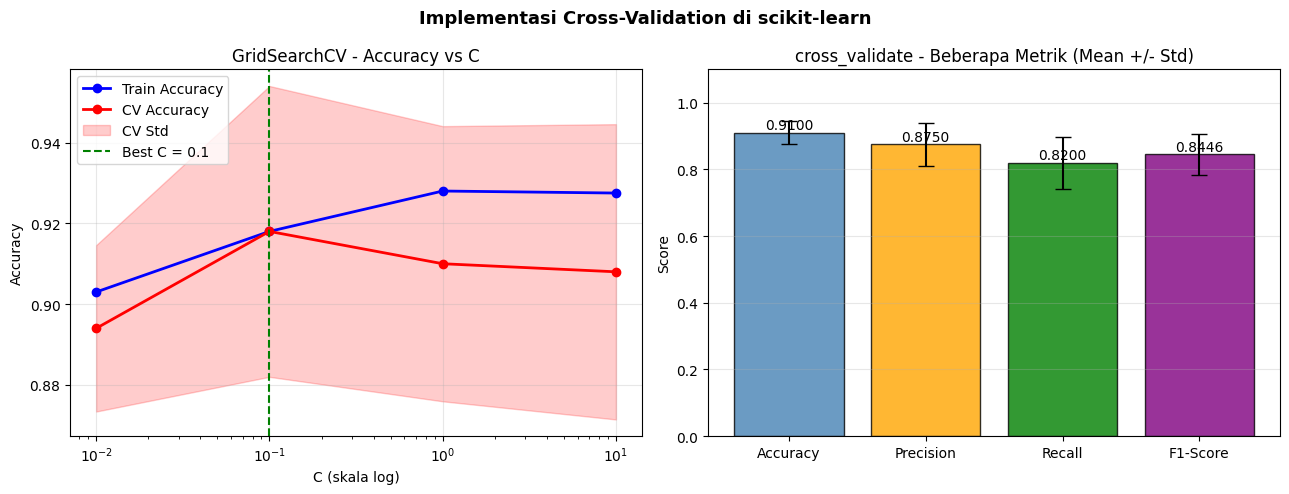

In [14]:
# Visualisasi hasil GridSearchCV
C_vals = [float(c) for c in cv_results['param_C']]
mean_test  = cv_results['mean_test_score']
mean_train = cv_results['mean_train_score']
std_test   = cv_results['std_test_score']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.semilogx(C_vals, mean_train, 'b-o', linewidth=2, label='Train Accuracy')
ax1.semilogx(C_vals, mean_test,  'r-o', linewidth=2, label='CV Accuracy')
ax1.fill_between(C_vals,
                 mean_test - std_test, mean_test + std_test,
                 alpha=0.2, color='red', label='CV Std')
ax1.axvline(grid_search.best_params_['C'], color='green', linestyle='--',
            label=f'Best C = {grid_search.best_params_["C"]}')
ax1.set_xlabel('C (skala log)')
ax1.set_ylabel('Accuracy')
ax1.set_title('GridSearchCV - Accuracy vs C')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Visualisasi cross_validate multi-metric
metric_names_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
mean_scores = [np.mean(v) for v in metrics_cv.values()]
std_scores  = [np.std(v)  for v in metrics_cv.values()]

bars = ax2.bar(metric_names_plot, mean_scores,
               color=['steelblue', 'orange', 'green', 'purple'],
               edgecolor='k', alpha=0.8, yerr=std_scores, capsize=6)
for bar, val in zip(bars, mean_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontsize=10)
ax2.set_ylim(0, 1.1)
ax2.set_title('cross_validate - Beberapa Metrik (Mean +/- Std)')
ax2.set_ylabel('Score')
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Implementasi Cross-Validation di scikit-learn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Teknik Pemilihan Model

### Penjelasan Teori

Setelah mengevaluasi model dengan cross-validation, langkah selanjutnya adalah memilih konfigurasi model terbaik untuk deployment. Dua strategi utama:

**GridSearchCV (Exhaustive Search):**
- Mencoba setiap kombinasi hyperparameter yang ditentukan secara eksplisit.
- Menghasilkan hasil yang dapat direproduksi dan komprehensif.
- **Kelemahan**: Kompleksitas komputasi tumbuh secara eksponensial dengan jumlah parameter dan nilai yang diuji.

**RandomizedSearchCV (Random Sampling):**
- Mengambil sampel acak dari distribusi parameter yang ditentukan.
- Jumlah evaluasi dikontrol dengan parameter `n_iter`.
- **Keunggulan**: Lebih efisien untuk ruang parameter yang besar. Penelitian menunjukkan bahwa random search sering menemukan kombinasi yang hampir sama baiknya dengan grid search, dengan lebih sedikit evaluasi.
- Cocok untuk eksplorasi awal sebelum grid search yang lebih terfokus.

**Praktik terbaik dalam pemilihan model:**
1. Tentukan metrik evaluasi yang sesuai dengan konteks bisnis (bukan selalu accuracy).
2. Gunakan cross-validation pada data training, lalu evaluasi model terbaik pada test set yang terpisah.
3. Pertimbangkan trade-off antara performa, kecepatan inferensi, dan interpretabilitas.

In [15]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, train_test_split
)
from sklearn.metrics import accuracy_score
from scipy.stats import loguniform
import time

X_ms, y_ms = make_classification(
    n_samples=500, n_features=10,
    weights=[0.7, 0.3], random_state=2024
)
X_ms_train, X_ms_test, y_ms_train, y_ms_test = train_test_split(
    X_ms, y_ms, test_size=0.3, random_state=2024
)

In [16]:
# GridSearchCV
param_grid_ms = {"C": [0.001, 0.01, 0.1, 1, 10, 100]}

start_grid = time.time()
grid_ms = GridSearchCV(
    LogisticRegression(max_iter=1000), param_grid_ms,
    cv=5, scoring='accuracy'
)
grid_ms.fit(X_ms_train, y_ms_train)
time_grid = time.time() - start_grid

print("GridSearchCV:")
print(f"  Parameter terbaik: C = {grid_ms.best_params_['C']}")
print(f"  CV Accuracy terbaik: {grid_ms.best_score_:.4f}")
print(f"  Waktu komputasi: {time_grid:.4f} detik")

GridSearchCV:
  Parameter terbaik: C = 0.1
  CV Accuracy terbaik: 0.8943
  Waktu komputasi: 0.4066 detik


In [17]:
# RandomizedSearchCV
param_dist_ms = {"C": loguniform(1e-3, 1e2)}

start_rand = time.time()
rand_ms = RandomizedSearchCV(
    LogisticRegression(max_iter=1000),
    param_distributions=param_dist_ms,
    n_iter=10, cv=5, scoring='accuracy',
    random_state=2024
)
rand_ms.fit(X_ms_train, y_ms_train)
time_rand = time.time() - start_rand

print("RandomizedSearchCV:")
print(f"  Parameter terbaik: C = {rand_ms.best_params_['C']:.4f}")
print(f"  CV Accuracy terbaik: {rand_ms.best_score_:.4f}")
print(f"  Waktu komputasi: {time_rand:.4f} detik")

RandomizedSearchCV:
  Parameter terbaik: C = 0.1744
  CV Accuracy terbaik: 0.8971
  Waktu komputasi: 0.9276 detik


In [18]:
# Evaluasi model terbaik pada test set
best_grid  = grid_ms.best_estimator_
best_rand  = rand_ms.best_estimator_

acc_grid = accuracy_score(y_ms_test, best_grid.predict(X_ms_test))
acc_rand = accuracy_score(y_ms_test, best_rand.predict(X_ms_test))

comparison_df = pd.DataFrame({
    'Metode': ['GridSearchCV', 'RandomizedSearchCV'],
    'Best C': [grid_ms.best_params_['C'],
               round(rand_ms.best_params_['C'], 4)],
    'CV Accuracy': [round(grid_ms.best_score_, 4),
                    round(rand_ms.best_score_, 4)],
    'Test Accuracy': [round(acc_grid, 4), round(acc_rand, 4)],
    'Waktu (detik)': [round(time_grid, 4), round(time_rand, 4)]
})

print("Perbandingan GridSearchCV vs RandomizedSearchCV:")
display(comparison_df.set_index('Metode'))
print()
print("Kesimpulan: RandomizedSearchCV mencapai performa serupa dengan waktu lebih singkat.")

Perbandingan GridSearchCV vs RandomizedSearchCV:


,Best C,CV Accuracy,Test Accuracy,Waktu (detik)
Metode,,,,
GridSearchCV,0.1000,0.8943,0.9333,0.4066
RandomizedSearchCV,0.1744,0.8971,0.9400,0.9276



Kesimpulan: RandomizedSearchCV mencapai performa serupa dengan waktu lebih singkat.


---
## 5. Evaluasi Kemampuan Generalisasi Model

### Penjelasan Teori

Salah satu tantangan utama dalam machine learning adalah memastikan model tidak hanya bekerja baik pada data training, tapi juga pada data baru. Dua alat diagnostik utama:

**Learning Curve:**
- Plot performa model (training vs validasi) sebagai fungsi dari ukuran dataset training.
- Membantu menjawab: apakah model butuh lebih banyak data?
- **Interpretasi:**
  - Gap besar antara training dan validasi: **overfitting** (model terlalu kompleks atau terlalu sedikit data).
  - Kedua kurva konvergen di nilai rendah: **underfitting** (model terlalu sederhana).
  - Kedua kurva konvergen di nilai tinggi: **generalisasi baik**.

**Validation Curve:**
- Plot performa model sebagai fungsi dari nilai hyperparameter tertentu.
- Membantu menjawab: nilai hyperparameter mana yang optimal?
- **Interpretasi:**
  - Nilai hyperparameter terlalu kecil (regularisasi terlalu kuat): underfitting (training dan validasi sama-sama rendah).
  - Nilai hyperparameter terlalu besar (regularisasi terlalu lemah): overfitting (training tinggi, validasi rendah).
  - Titik optimal: trade-off terbaik antara training dan validasi score.

**Bias-Variance Trade-off:**
- **Bias tinggi (underfitting)**: Model terlalu sederhana, tidak mampu menangkap pola data.
- **Variance tinggi (overfitting)**: Model terlalu kompleks, menghafal noise data training.
- Tujuan: temukan keseimbangan optimal antara bias dan variance.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve, validation_curve

# Dataset yang lebih besar untuk learning curve yang informatif
X_lc, y_lc = make_classification(
    n_samples=1000, n_features=20,
    weights=[0.7, 0.3], random_state=2024
)

print(f"Dataset untuk Learning Curve: {X_lc.shape}")

Dataset untuk Learning Curve: (1000, 20)


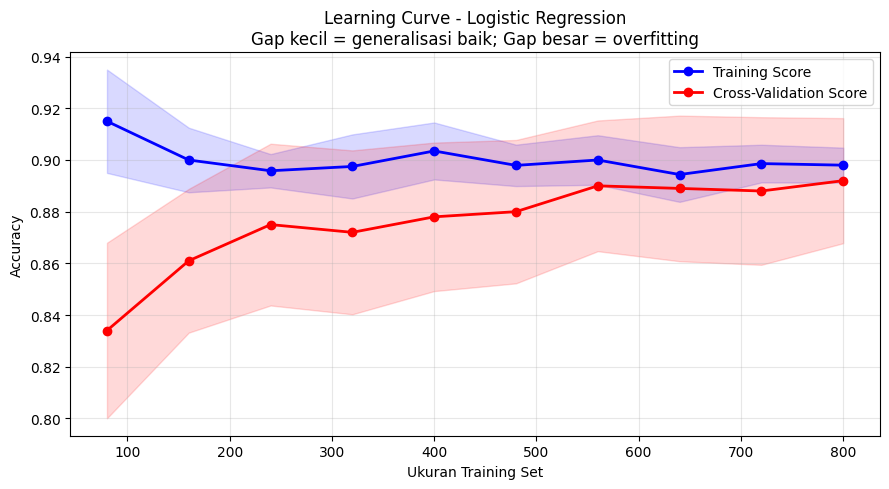

Interpretasi:
  Training Score (n_max):    0.8980
  CV Score (n_max):          0.8920
  Gap akhir:                 0.0060


In [20]:
# Learning Curve
train_sizes, train_scores_lc, test_scores_lc = learning_curve(
    LogisticRegression(max_iter=1000), X_lc, y_lc, cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=2024
)

train_mean_lc = np.mean(train_scores_lc, axis=1)
train_std_lc  = np.std(train_scores_lc, axis=1)
test_mean_lc  = np.mean(test_scores_lc, axis=1)
test_std_lc   = np.std(test_scores_lc, axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean_lc, 'b-o', lw=2, label='Training Score')
plt.plot(train_sizes, test_mean_lc,  'r-o', lw=2, label='Cross-Validation Score')
plt.fill_between(train_sizes,
                 train_mean_lc - train_std_lc, train_mean_lc + train_std_lc,
                 alpha=0.15, color='blue')
plt.fill_between(train_sizes,
                 test_mean_lc - test_std_lc, test_mean_lc + test_std_lc,
                 alpha=0.15, color='red')
plt.xlabel('Ukuran Training Set')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Logistic Regression\n'
          'Gap kecil = generalisasi baik; Gap besar = overfitting')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretasi:")
print(f"  Training Score (n_max):    {train_mean_lc[-1]:.4f}")
print(f"  CV Score (n_max):          {test_mean_lc[-1]:.4f}")
print(f"  Gap akhir:                 {train_mean_lc[-1] - test_mean_lc[-1]:.4f}")

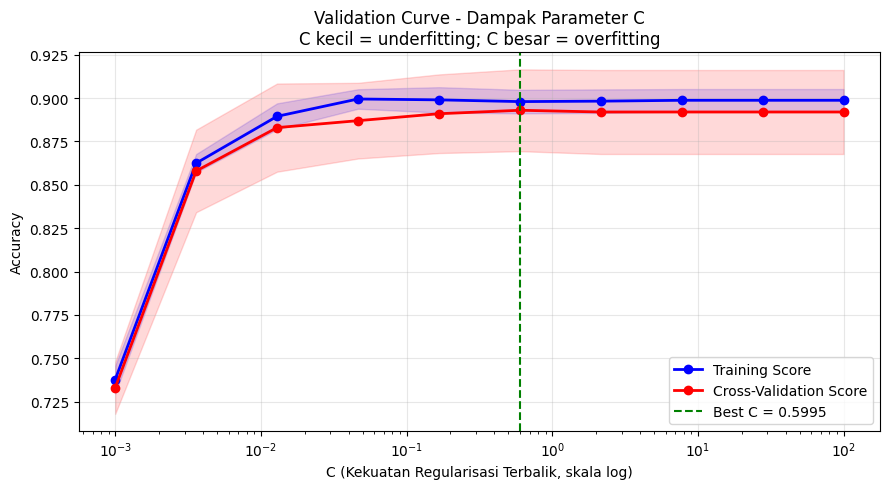

Nilai C optimal berdasarkan CV score: 0.5995
CV Accuracy pada C optimal: 0.8930


In [21]:
# Validation Curve: dampak hyperparameter C
param_range_vc = np.logspace(-3, 2, 10)

train_scores_vc, test_scores_vc = validation_curve(
    LogisticRegression(max_iter=1000), X_lc, y_lc,
    param_name="C", param_range=param_range_vc,
    cv=5, scoring='accuracy'
)

train_mean_vc = np.mean(train_scores_vc, axis=1)
train_std_vc  = np.std(train_scores_vc, axis=1)
test_mean_vc  = np.mean(test_scores_vc, axis=1)
test_std_vc   = np.std(test_scores_vc, axis=1)

best_c_idx = np.argmax(test_mean_vc)
best_c_val = param_range_vc[best_c_idx]

plt.figure(figsize=(9, 5))
plt.semilogx(param_range_vc, train_mean_vc, 'b-o', lw=2, label='Training Score')
plt.semilogx(param_range_vc, test_mean_vc,  'r-o', lw=2, label='Cross-Validation Score')
plt.fill_between(param_range_vc,
                 train_mean_vc - train_std_vc, train_mean_vc + train_std_vc,
                 alpha=0.15, color='blue')
plt.fill_between(param_range_vc,
                 test_mean_vc - test_std_vc, test_mean_vc + test_std_vc,
                 alpha=0.15, color='red')
plt.axvline(best_c_val, color='green', linestyle='--',
            label=f'Best C = {best_c_val:.4f}')
plt.xlabel('C (Kekuatan Regularisasi Terbalik, skala log)')
plt.ylabel('Accuracy')
plt.title('Validation Curve - Dampak Parameter C\n'
          'C kecil = underfitting; C besar = overfitting')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Nilai C optimal berdasarkan CV score: {best_c_val:.4f}")
print(f"CV Accuracy pada C optimal: {test_mean_vc[best_c_idx]:.4f}")

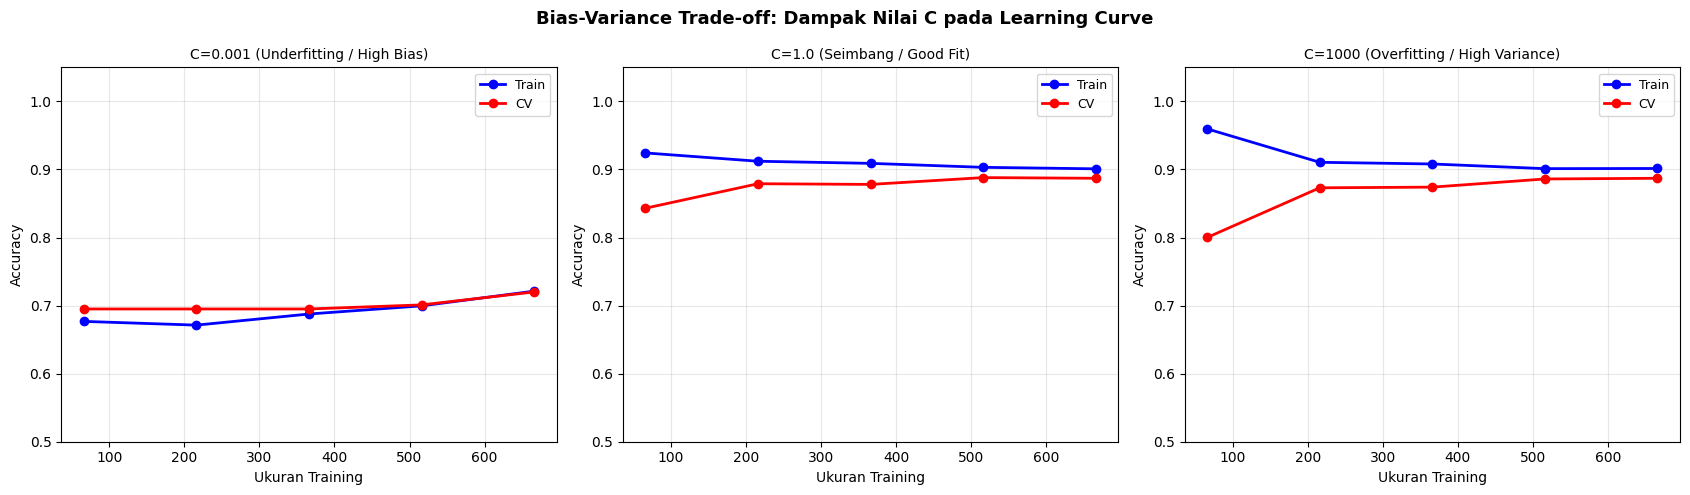

In [22]:
# Diagram Bias-Variance Trade-off
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

C_scenarios = [
    (0.001, 'C=0.001 (Underfitting / High Bias)'),
    (1.0,   'C=1.0 (Seimbang / Good Fit)'),
    (1000,  'C=1000 (Overfitting / High Variance)')
]

for ax, (C_val, title) in zip(axes, C_scenarios):
    ts, tr_s, te_s = learning_curve(
        LogisticRegression(C=C_val, max_iter=10000),
        X_lc, y_lc, cv=3,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='accuracy',
        random_state=2024
    )
    ax.plot(ts, np.mean(tr_s, axis=1), 'b-o', lw=2, label='Train')
    ax.plot(ts, np.mean(te_s, axis=1), 'r-o', lw=2, label='CV')
    ax.set_ylim(0.5, 1.05)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Ukuran Training')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Bias-Variance Trade-off: Dampak Nilai C pada Learning Curve',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Latihan Komprehensif: Pipeline Evaluasi Lengkap

### Deskripsi

Latihan ini menggabungkan semua teknik yang dipelajari dalam satu pipeline evaluasi model yang komprehensif: dari cross-validation awal, hyperparameter tuning dengan GridSearchCV, hingga evaluasi final pada test set.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_validate, learning_curve
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
from sklearn.datasets import make_classification

# Dataset final
X_final, y_final = make_classification(
    n_samples=800, n_features=15, n_informative=10,
    n_redundant=5, weights=[0.65, 0.35], random_state=2024
)

# Pisahkan test set yang tidak akan pernah disentuh selama tuning
X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=2024, stratify=y_final
)

print(f"Dataset Final:")
print(f"  Training set: {X_f_train.shape}")
print(f"  Test set:     {X_f_test.shape}")
print(f"  Train class ratio: {y_f_train.mean():.3f}")
print(f"  Test class ratio:  {y_f_test.mean():.3f}")

Dataset Final:
  Training set: (640, 15)
  Test set:     (160, 15)
  Train class ratio: 0.353
  Test class ratio:  0.356


In [24]:
# Step 1: Pipeline dengan preprocessing
pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=10000, random_state=2024))
])

# Step 2: Evaluasi awal dengan cross_validate
cv_initial = cross_validate(
    pipeline_final, X_f_train, y_f_train, cv=5,
    scoring=['accuracy', 'f1', 'roc_auc']
)

print("Evaluasi Awal (Baseline Pipeline, CV=5):")
print(f"  Accuracy:  {np.mean(cv_initial['test_accuracy']):.4f} (+/- {np.std(cv_initial['test_accuracy']):.4f})")
print(f"  F1-Score:  {np.mean(cv_initial['test_f1']):.4f} (+/- {np.std(cv_initial['test_f1']):.4f})")
print(f"  ROC-AUC:   {np.mean(cv_initial['test_roc_auc']):.4f} (+/- {np.std(cv_initial['test_roc_auc']):.4f})")

Evaluasi Awal (Baseline Pipeline, CV=5):
  Accuracy:  0.7578 (+/- 0.0204)
  F1-Score:  0.6125 (+/- 0.0395)
  ROC-AUC:   0.7833 (+/- 0.0376)


In [25]:
# Step 3: Hyperparameter tuning dengan GridSearchCV
param_grid_final = {
    'clf__C':       [0.01, 0.1, 1.0, 10.0, 100.0],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver':  ['liblinear']
}

gs_final = GridSearchCV(
    pipeline_final, param_grid_final,
    cv=5, scoring='roc_auc', n_jobs=-1,
    return_train_score=True
)
gs_final.fit(X_f_train, y_f_train)

print("GridSearchCV - Hyperparameter Tuning:")
print(f"  Parameter terbaik: {gs_final.best_params_}")
print(f"  CV ROC-AUC terbaik: {gs_final.best_score_:.4f}")

GridSearchCV - Hyperparameter Tuning:
  Parameter terbaik: {'clf__C': 100.0, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
  CV ROC-AUC terbaik: 0.7845


In [26]:
# Step 4: Evaluasi final pada test set
best_model = gs_final.best_estimator_
y_pred_final = best_model.predict(X_f_test)
y_prob_final = best_model.predict_proba(X_f_test)[:, 1]

acc_f   = accuracy_score(y_f_test, y_pred_final)
prec_f  = precision_score(y_f_test, y_pred_final)
rec_f   = recall_score(y_f_test, y_pred_final)
f1_f    = f1_score(y_f_test, y_pred_final)
auc_f   = roc_auc_score(y_f_test, y_prob_final)

final_metrics = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Score': [acc_f, prec_f, rec_f, f1_f, auc_f]
}).set_index('Metrik').round(4)

print("Evaluasi Final pada Test Set (Model Terbaik):")
display(final_metrics)

print()
print("Classification Report:")
print(classification_report(
    y_f_test, y_pred_final,
    target_names=['Kelas 0', 'Kelas 1']
))

Evaluasi Final pada Test Set (Model Terbaik):


,Score
Metrik,
Accuracy,0.7125
Precision,0.6279
Recall,0.4737
F1-Score,0.5400
ROC-AUC,0.7024



Classification Report:
              precision    recall  f1-score   support

     Kelas 0       0.74      0.84      0.79       103
     Kelas 1       0.63      0.47      0.54        57

    accuracy                           0.71       160
   macro avg       0.69      0.66      0.67       160
weighted avg       0.70      0.71      0.70       160



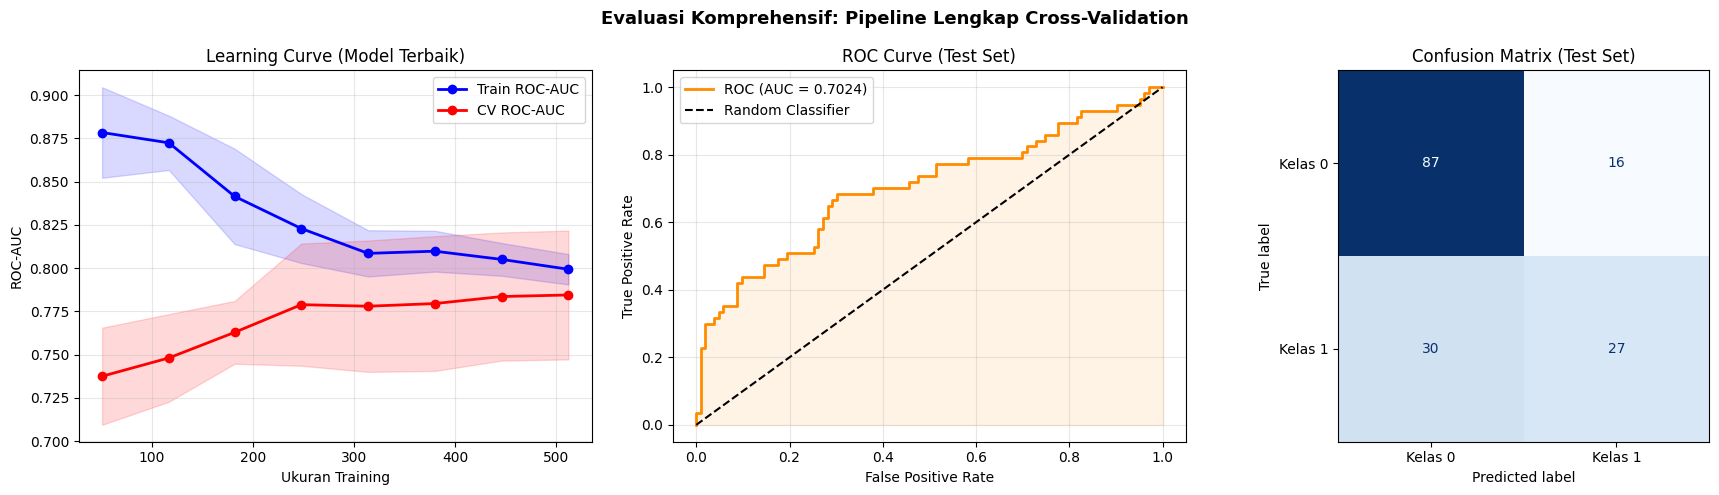

In [27]:
# Visualisasi komprehensif: Learning Curve model terbaik
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ts_best, tr_best, te_best = learning_curve(
    best_model, X_f_train, y_f_train, cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8),
    random_state=2024
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Learning Curve model terbaik
axes[0].plot(ts_best, np.mean(tr_best, axis=1), 'b-o', lw=2, label='Train ROC-AUC')
axes[0].plot(ts_best, np.mean(te_best, axis=1), 'r-o', lw=2, label='CV ROC-AUC')
axes[0].fill_between(
    ts_best,
    np.mean(tr_best, axis=1) - np.std(tr_best, axis=1),
    np.mean(tr_best, axis=1) + np.std(tr_best, axis=1),
    alpha=0.15, color='blue'
)
axes[0].fill_between(
    ts_best,
    np.mean(te_best, axis=1) - np.std(te_best, axis=1),
    np.mean(te_best, axis=1) + np.std(te_best, axis=1),
    alpha=0.15, color='red'
)
axes[0].set_xlabel('Ukuran Training')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('Learning Curve (Model Terbaik)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: ROC Curve
fpr_f, tpr_f, _ = roc_curve(y_f_test, y_prob_final)
axes[1].plot(fpr_f, tpr_f, color='darkorange', lw=2,
             label=f'ROC (AUC = {auc_f:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
axes[1].fill_between(fpr_f, tpr_f, alpha=0.1, color='darkorange')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Test Set)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: Confusion Matrix
cm_final = confusion_matrix(y_f_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final,
                               display_labels=['Kelas 0', 'Kelas 1'])
disp.plot(ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('Confusion Matrix (Test Set)')

plt.suptitle('Evaluasi Komprehensif: Pipeline Lengkap Cross-Validation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Ringkasan Chapter 12

| Konsep | Kelas/Fungsi scikit-learn | Deskripsi |
|--------|--------------------------|-----------|
| K-Fold CV | `KFold()` | Bagi data menjadi k folds, rotasi training-test |
| Stratified K-Fold | `StratifiedKFold()` | K-Fold dengan distribusi kelas seimbang per fold |
| Leave-One-Out CV | `LeaveOneOut()` | Setiap sampel sekali menjadi test set |
| Evaluasi Satu Metrik | `cross_val_score()` | Hitung satu metrik secara cross-validated |
| Evaluasi Multi-Metrik | `cross_validate()` | Hitung beberapa metrik sekaligus |
| Grid Search | `GridSearchCV()` | Exhaustive hyperparameter tuning dengan CV |
| Random Search | `RandomizedSearchCV()` | Sampling acak parameter dengan CV |
| Learning Curve | `learning_curve()` | Performa vs ukuran data (diagnosis bias-variance) |
| Validation Curve | `validation_curve()` | Performa vs nilai hyperparameter |

### Poin Kunci untuk Diingat:

1. **Cross-validation lebih andal** dari single train-test split karena mengurangi variance estimasi performa melalui averaging atas beberapa pemisahan data.

2. **Gunakan StratifiedKFold** untuk dataset klasifikasi yang tidak seimbang agar setiap fold merepresentasikan distribusi kelas asli.

3. **LOOCV** memberikan estimasi yang hampir tidak bias tapi sangat mahal secara komputasi. Gunakan hanya untuk dataset kecil.

4. **Nested CV** adalah cara yang benar untuk menggabungkan hyperparameter tuning dan evaluasi model tanpa kebocoran data (data leakage).

5. **GridSearchCV mencoba semua kombinasi**; RandomizedSearchCV mengambil sampel acak. Untuk ruang parameter yang besar, RandomizedSearchCV lebih efisien.

6. **Learning Curve** membantu mendiagnosis overfitting (gap besar antara training dan validasi) vs underfitting (kedua kurva rendah dan konvergen).

7. **Validation Curve** menunjukkan dampak hyperparameter terhadap performa, membantu menemukan nilai optimal.

8. **Selalu evaluasi model terbaik pada test set yang terpisah** dan tidak pernah digunakan selama proses tuning untuk mendapatkan estimasi performa yang jujur.